# 00c · EDA de Rappi: venta de sueros e hidratación — ZM de la ciudad activa

**Papel en el flujo:** Rappi es una fuente **externa** de venta de sueros e hidratación (no es del cliente). Aquí se hace
el EDA con los mismos pasos del 00 y del 00b (método retail-math-eda) y se deja, por **tienda física**, la venta que el
notebook 06 usa en la **Letra 2**: el Rappi de cada PDV es la venta media de las tiendas Rappi de su buffer de 300 m, que
entra al score de rangos con la mitad del peso de la venta y el CP.

**Usar solo la data correcta (decisión del usuario): sueros e hidratación de la ciudad activa.** Si una línea viene con
otros productos, lo que importa es que tenga **sueros o sus derivados**.

| Filtro | Regla | Cómo se verifica (sección 1) |
|---|---|---|
| Ciudad | tiendas **dentro de los municipios de la ZM** (polígono del Marco Geoestadístico) | la etiqueta `city` de Rappi de esas líneas debe ser la de la ciudad, y ninguna línea con esa etiqueta debe quedar fuera |
| Producto | **sueros** (Rappi: "Hidratantes Líquidos") y **derivados** ("Isotónicos Líquidos"), regla "sueros primero": subcategoría de Rappi → la de su marca → el nombre del producto → la categoría de hidratación | tabla por regla; solo sale lo que tiene evidencia de no ser suero (Vitamin Water = agua funcional, refrescos) |
| Ventana | ene-2025 → ago-2026: termina con las ventas de Bepensa (00); empieza cuando el archivo tiene cobertura completa | tabla nacional por mes (cadena, vertical y marcas que aparecen tarde) |

**Fuente:** `data/raw/rappi/rappi.csv` (nacional; no se sube a git). Una fila = **una línea de pedido** (pedido × producto):
fecha-hora, tienda (id, nombre, cadena, vertical, lat/lon), producto (categorías, marca, fabricante; los competidores de
Coca-Cola vienen **anonimizados**: marca `BRAND_####`, sin SKU, nombre ni usuario; **esas líneas no se toman**, usuario 2026-10-05), importe (`beverage_sales`, MXN) y unidades.

**Convenciones (retail-math-eda):** grano = línea de pedido; importe en MXN tal como lo reporta Rappi (sin devoluciones:
se verifica que no haya negativos); con muchas pruebas la p se corrige con Benjamini-Hochberg y se decide por **tamaño de
efecto** (δ de Cliff, ε², V de Cramér) con IC95; semilla fija `eda.SEMILLA`.

**Reproducir:** no depende de otros notebooks (el Marco Geoestadístico se descarga solo): `python src/correr.py --pasos 00c merida`.

In [1]:
import os
import sys
import platform
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import hashlib
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import BallTree
from IPython.display import display

import config as C
import eda
import rappi as R
from descargas import descargar_fuente, extraer

eda.estilo()
rng = np.random.default_rng(eda.SEMILLA)
AZUL, NARANJA, VERDE, AMBAR, ROSA, VERDE2, MORADO, ROJO = eda.PALETA
SUEROS, ISOTONICOS = C.RAPPI_SUBCATEGORIAS["Hidratantes Líquidos"], C.RAPPI_SUBCATEGORIAS["Isotónicos Líquidos"]
ini, fin = pd.Timestamp(C.RAPPI_VENTANA[0]), pd.Timestamp(C.RAPPI_VENTANA[1])      # [ini, fin): justificación en la sección 1.3
cierre = fin - pd.Timedelta(days=1)
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
mes_txt = lambda t: f"{MESES[t.month - 1]}-{t.year}"
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
print(f"Repo: {BASE} | ciudad: {C.ZM_NOMBRE} | semilla: {eda.SEMILLA} | Python {platform.python_version()} · pandas {pd.__version__}")

# procedencia (igual que 00 y 00b): archivo, filas, fecha y SHA-256
assert C.RAPPI_CSV.exists(), f"Falta {C.RAPPI_CSV}: copiar la exportación de Rappi (rappi.csv) a data/raw/rappi/"
h = hashlib.sha256()
with open(C.RAPPI_CSV, "rb") as f:
    for bloque in iter(lambda: f.read(1 << 24), b""):
        h.update(bloque)
nac = pd.read_csv(C.RAPPI_CSV, usecols=R.COLUMNAS, engine="pyarrow")
FILAS_ARCHIVO = len(nac)
# no se toma lo que dice BRAND_x (usuario, 2026-10-05): marcas anonimizadas de competidores, sin SKU, nombre ni usuario
es_brand_x = nac.Product_Brand.fillna("").str.match(C.RAPPI_EXCLUIR_MARCA)
print(f"Líneas con marca BRAND_x que NO se toman: {es_brand_x.sum():,} de {len(nac):,} ({es_brand_x.mean():.1%}; "
      f"{nac.beverage_sales[es_brand_x].sum() / nac.beverage_sales.sum():.1%} del importe nacional)")
nac = nac[~es_brand_x].reset_index(drop=True)
FUENTES_RAPPI = pd.DataFrame([{
    "insumo": "Rappi (venta en línea, nacional)", "archivo": C.RAPPI_CSV.name, "ruta": str(C.RAPPI_CSV.relative_to(BASE)),
    "bytes": C.RAPPI_CSV.stat().st_size, "filas": FILAS_ARCHIVO, "filas sin BRAND_x": len(nac),
    "modificado": datetime.fromtimestamp(C.RAPPI_CSV.stat().st_mtime).strftime("%Y-%m-%d %H:%M"), "sha256": h.hexdigest()}])
FUENTES_RAPPI.to_csv(C.PROC / "fuentes_rappi_00c.csv", index=False)
display(FUENTES_RAPPI)
descargar_fuente(C.FUENTES["mg"])       # polígonos municipales y de AGEB (no vuelve a bajar si ya está)
D_MG = extraer(C.ARCHIVOS["mg"])

Repo: C:\Users\KIN\Desktop\Kin\mx-retail-geodemographics | ciudad: ZM Mérida | semilla: 2026 | Python 3.14.6 · pandas 3.0.5


Líneas con marca BRAND_x que NO se toman: 488,683 de 864,704 (56.5%; 58.0% del importe nacional)


,insumo,archivo,ruta,bytes,filas,filas sin BRAND_x,modificado,sha256
0,"Rappi (venta en línea, nacional)",rappi.csv,data\raw\rappi\rappi.csv,769256482,864704,376021,2026-09-29 18:17,0ef78005500263a7824c4306bccf588f67f8addc168219...


[ok] ya existe mg2025eic_31_yucatan.zip


## 1. ¿Estamos tomando la data correcta? Ciudad, producto y ventana
### 1.1 Ciudad: etiqueta de Rappi contra el polígono de la ZM

El universo se define por **ubicación de la tienda dentro de los municipios de la ZM** (mismo criterio que los PDV de
Bepensa en el 00). La etiqueta `city` se normaliza (sin acentos ni mayúsculas: "Mérida" y "Merida" son la misma) y se
cruza con el polígono: si la data es correcta, todas las líneas dentro de la ZM traen la etiqueta de la ciudad y ninguna
línea con esa etiqueta cae fuera.

In [2]:
nac["ciudad_n"] = R.normalizar(nac.city)
nac["fecha"] = pd.to_datetime(nac["datetime"], utc=True).dt.tz_localize(None)   # reloj local (sección 1.3): la "Z" no es UTC real
nac["mes"] = nac.fecha.dt.strftime("%Y-%m")
mun = gpd.read_file(next(D_MG.rglob(f"{C.ENT}mun.shp")))[["CVE_MUN", "NOMGEO", "geometry"]]
zm = mun[mun.CVE_MUN.isin(C.ZM_MUNICIPIOS)]
agebs = gpd.read_file(next(D_MG.rglob(f"{C.ENT}a.shp")))
agebs = agebs[agebs.CVE_MUN.isin(C.ZM_MUNICIPIOS)]
x0, y0, x1, y1 = zm.to_crs(4326).total_bounds
etiqueta = nac.ciudad_n.isin(C.RAPPI_CIUDAD)
caja = nac.store_lat.between(y0 - 0.1, y1 + 0.1) & nac.store_lng.between(x0 - 0.1, x1 + 0.1)
cand = nac[etiqueta | caja].copy()                         # candidatos: la etiqueta o una caja amplia alrededor de la ZM
con_xy = cand.store_lat.notna() & cand.store_lng.notna()
pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(cand.store_lng[con_xy], cand.store_lat[con_xy]),
                       index=cand.index[con_xy], crs=4326).to_crs(mun.crs)
j = gpd.sjoin(pts, mun, how="left", predicate="within")
j = j[~j.index.duplicated()]
cand["cve_mun"], cand["municipio"] = j.CVE_MUN.reindex(cand.index), j.NOMGEO.reindex(cand.index)
cand["en_zm"] = cand.cve_mun.isin(C.ZM_MUNICIPIOS)
cand["etiqueta_ciudad"] = cand.ciudad_n.isin(C.RAPPI_CIUDAD)

etiquetas = nac[etiqueta].groupby(["city", "Source_Ship_From_Code", "State"], dropna=False).size().rename("líneas").reset_index()
print(f"Etiquetas de Rappi que normalizadas son {C.RAPPI_CIUDAD}:")
display(etiquetas)
ubic = np.select([~con_xy, cand.en_zm], ["sin coordenadas", f"dentro de la {C.ZM_NOMBRE}"], "fuera de la ZM")
cruce_ciudad = pd.crosstab(np.where(cand.etiqueta_ciudad, f"etiqueta {'/'.join(C.RAPPI_CIUDAD)}", "otra etiqueta"), ubic,
                           rownames=["etiqueta city"], colnames=["ubicación de la tienda"])
display(cruce_ciudad)
display(cand[cand.en_zm].municipio.value_counts().rename("líneas").to_frame())
fuera = cand[cand.etiqueta_ciudad & ~cand.en_zm][["store_id", "store_name", "store_lat", "store_lng", "Source_Platform_Type"]].drop_duplicates()
print(f"Líneas con la etiqueta de la ciudad fuera de la ZM o sin coordenadas: {int((cand.etiqueta_ciudad & ~cand.en_zm).sum())} "
      f"| líneas dentro de la ZM con otra etiqueta: {int((~cand.etiqueta_ciudad & cand.en_zm).sum())}")
display(fuera)

Etiquetas de Rappi que normalizadas son ['MERIDA']:


,city,Source_Ship_From_Code,State,líneas
0,Merida,MXMerida,NaN,7945
1,Mérida,MXMérida,NaN,7134
2,Mérida,MXYUCMérida,YUC,3


ubicación de la tienda,dentro de la ZM Mérida,sin coordenadas
etiqueta city,,
etiqueta MERIDA,15078,4


,líneas
municipio,
Mérida,14810
Kanasín,185
Conkal,82
Umán,1


Líneas con la etiqueta de la ciudad fuera de la ZM o sin coordenadas: 4 | líneas dentro de la ZM con otra etiqueta: 0


,store_id,store_name,store_lat,store_lng,Source_Platform_Type
23168,1923732873,Green Fitness Food Mid,20.994,NaN,Food Delivery
95234,1930452894,el Burguesse Cholul - C. 21 111,21.043,NaN,Food Delivery
165734,1930103953,Vaquero's Pizza,20.937,NaN,Food Delivery


### 1.2 Producto: sueros y sus derivados ("sueros primero")

Rappi clasifica en `Product_Category_3`: **"Hidratantes Líquidos" = sueros** (rehidratantes con electrolitos: Flashlyte y
las marcas anonimizadas de sueros) e **"Isotónicos Líquidos" = derivados** (bebidas con electrolitos: Powerade y su
competidor). Además trae un nodo **genérico** ("Bebidas Hidratantes"), filas "No disponible" y, en otras categorías, sueros y
combos con isotónicos. Regla (`rappi.clasificar`; la primera que aplica gana):

1. la subcategoría de Rappi; 2. la de su **marca** en todo el país (si la marca es pura: ≥ 95% de sus líneas en una sola
subcategoría); 3. el **nombre del producto** (suero, electrolito, rehidratante → suero; Powerade, Gatorade, isotónica →
derivado), en cualquier categoría; 4. si está en la categoría de hidratación, **entra** como "hidratación sin subcategoría"
(puede ser suero). Sale solo lo que tiene evidencia de **no** ser suero ni derivado: Vitamin Water (agua funcional; así la
clasifica Rappi en el resto del país) y lo que no es hidratación (refrescos, agua sola).

In [3]:
marcas = R.subcategoria_por_marca(nac, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)       # evidencia de todo el país
cand["subcategoria"], cand["regla"] = R.clasificar(cand, marcas, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)
nac_sub, nac_regla = R.clasificar(nac, marcas, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)
zmx = cand[cand.en_zm]
en_ventana = zmx.fecha.between(ini, fin, inclusive="left")
por_regla = pd.DataFrame({
    f"líneas {C.ZM_NOMBRE} (ventana)": zmx.regla[en_ventana].value_counts(), f"venta {C.ZM_NOMBRE} (ventana)": zmx[en_ventana].groupby("regla").beverage_sales.sum(),
    f"líneas {C.ZM_NOMBRE} (todo el archivo)": zmx.regla.value_counts(), "líneas país (todo el archivo)": nac_regla.value_counts(),
    "venta país (todo el archivo)": nac.beverage_sales.groupby(nac_regla).sum()}).fillna(0)
display(por_regla.round(0))
categorias = pd.crosstab([zmx.Product_Category_2.fillna("(vacío)"), zmx.Product_Category_3.fillna("(vacío)")],
                         zmx.subcategoria.fillna("NO ENTRA"), margins=True, margins_name="Total")
display(categorias)
reasignacion = (zmx[zmx.regla.str[0].isin(["2", "3", "4"]) | zmx.regla.str.startswith("no es suero")]
                .groupby(["Product_Maker_Standard", "Product_Brand", "Product_Category_2", "Product_Category_3", "regla", "subcategoria"], dropna=False)
                .agg(líneas=("order_code", "size"), venta=("beverage_sales", "sum")).reset_index().sort_values("líneas", ascending=False))
display(reasignacion)
fuera_cat = nac[nac_sub.notna() & ~nac.Product_Category_2.eq(C.RAPPI_CATEGORIA)]
print(f"Marcas con subcategoría específica en el país: {len(marcas)}; pureza mínima {marcas.pureza.min():.3f} (1 = la marca siempre cae "
      f"en una sola subcategoría). En el país, {len(fuera_cat):,} líneas de sueros o derivados vienen fuera de la categoría de "
      f"hidratación (p. ej. {', '.join(fuera_cat.Product_name.value_counts().index[:3])}) y entran por su nombre.")

,líneas ZM Mérida (ventana),venta ZM Mérida (ventana),líneas ZM Mérida (todo el archivo),líneas país (todo el archivo),venta país (todo el archivo)
0 · marca Coca-Cola de hidratación (Vitamin Water: agua funcional),16.000,866.000,108.000,9257,"585,290.000"
1 · subcategoría de Rappi,"13,114.000","641,899.000","13,287.000",309322,"14,018,266.000"
2 · subcategoría de su marca en el país,0.000,0.000,"1,683.000",56334,"2,236,534.000"
3 · nombre del producto,0.000,0.000,0.000,833,"49,316.000"
4 · categoría de hidratación sin subcategoría,0.000,0.000,0.000,34,"2,946.000"
no es hidratación (otra categoría),0.000,0.000,0.000,241,"15,657.000"


subcategoria                              Agua funcional (Vitamin Water)  Isotónicos (derivados)  Sueros (hidratantes)  Total
Product_Category_2  Product_Category_3                                                                                       
Agua                Agua Funcional                                    16                       0                     0     16
Bebidas Hidratantes Bebidas Hidratantes                               92                    1505                   178   1775
                    Hidratantes Líquidos                               0                       0                  2272   2272
                    Isotónicos Líquidos                                0                   11015                     0  11015
Total                                                                108                   12520                  2450  15078

,Product_Maker_Standard,Product_Brand,Product_Category_2,Product_Category_3,regla,subcategoria,líneas,venta
1,COCA-COLA,Powerade,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Isotónicos (derivados),1505,"61,683.110"
0,COCA-COLA,Flashlyte,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Sueros (hidratantes),178,"6,256.820"


Marcas con subcategoría específica en el país: 2; pureza mínima 1.000 (1 = la marca siempre cae en una sola subcategoría). En el país, 1,466 líneas de sueros o derivados vienen fuera de la categoría de hidratación (p. ej. Vitamin Water Bebida Isotónica Sabor Ponche De Frutas, Combo Ciel 1L + 2 Powerade Moras 1L, Vitamin Water Bebida Hidratante Sabor A Ponche De Frutas) y entran por su nombre.


### 1.3 Ventana, cobertura del archivo y reloj

* **Cobertura:** antes de fijar la ventana se revisa, en todo el país, si el archivo cambia de composición por mes (campos
  vacíos, marcas grandes que aparecen de golpe). Un cambio de cobertura no es demanda: si se mezcla, el crecimiento sale falso.
* **Reloj:** `datetime` viene con sufijo "Z" (UTC). Si fuera UTC real, en hora de Mérida (UTC−6) habría muchos pedidos de
  madrugada y casi ninguno en la noche. Se compara el perfil por hora tal como viene contra el convertido.

,líneas,venta,% sin cadena,% sin vertical
mes,,,,
2024-10,24481,"1,028,742.900",100.000,100.000
2024-11,21831,"932,640.200",100.000,100.000
2024-12,18806,"830,811.200",100.000,100.000
2025-01,16532,"697,770.500",0.000,0.000
2025-02,15891,"672,889.100",0.000,0.000
2025-03,19168,"875,052.600",0.000,0.000
2025-04,18266,"828,873.400",0.000,0.000
2025-05,20990,"935,508.700",0.000,0.000
2025-06,17025,"741,461.900",0.000,0.000


En 2024-10, 2024-11, 2024-12 el archivo no trae cadena ni vertical en todo el país: cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). La ventana empieza en ene-2025 (primer mes completo: 2025-01) y termina en ago-2026, igual que las ventas del cliente.
Líneas entre 1 y 6 h: 0.1% tal como viene vs 24.2% si fuera UTC: el reloj ya es hora local (no se convierte).
Rango del archivo en la ZM: 2024-10-01 08:00:00 → 2026-09-06 22:00:00 | ventana usada: 2025-01-01 → 2026-08-31
Ventas bepensa: 2024-10 → 2026-08 | mismo cierre: True


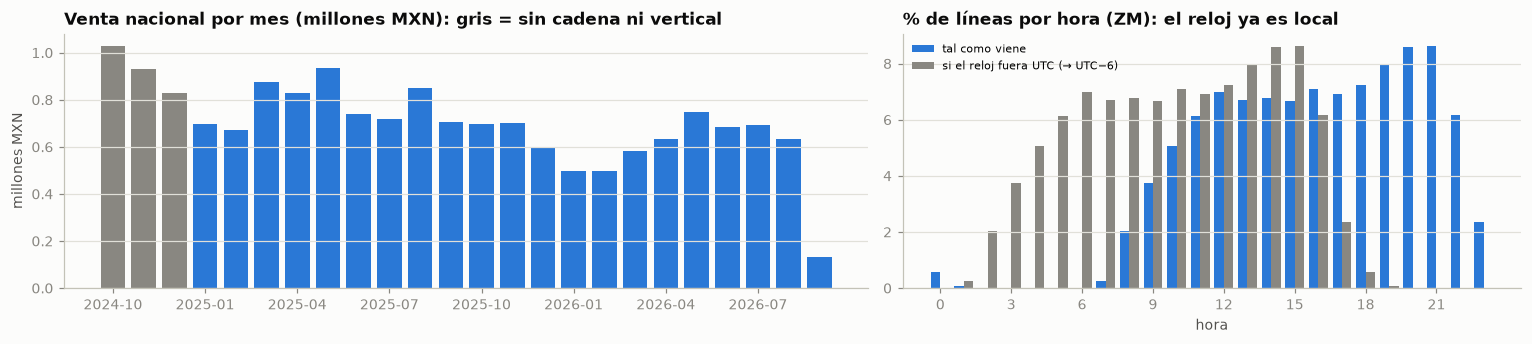

In [4]:
primera = nac.groupby("Product_Brand").mes.min()
peso = nac.groupby("Product_Brand").beverage_sales.sum() / nac.beverage_sales.sum()
tardias = primera[(primera > primera.min()) & (peso.reindex(primera.index) >= 0.01)]
cobertura = nac.groupby("mes").agg(líneas=("order_code", "size"), venta=("beverage_sales", "sum"),
                                   **{"% sin cadena": ("store_group_name", lambda s: s.isna().mean() * 100),
                                      "% sin vertical": ("vertical", lambda s: s.isna().mean() * 100)})
for b_ in tardias.index:
    cobertura[f"venta {b_} (entra {tardias[b_]}, {peso[b_]:.0%} del país)"] = nac[nac.Product_Brand.eq(b_)].groupby("mes").beverage_sales.sum()
display(cobertura.fillna(0).round(1))
completo = cobertura.index[(cobertura["% sin cadena"] < 1) & (cobertura["% sin vertical"] < 1)]
COBERTURA = (f"En {', '.join(cobertura.index[cobertura['% sin cadena'] >= 99])} el archivo no trae cadena ni vertical en todo el país"
             + (f" y {', '.join(tardias.index)} ({', '.join(f'{peso[b]:.0%}' for b in tardias.index)} de la venta nacional) aparece hasta "
                f"{', '.join(sorted(set(tardias)))}" if len(tardias) else "")
             + f": cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). "
               f"La ventana empieza en {mes_txt(ini)} (primer mes completo: {completo.min()}) y termina en {mes_txt(cierre)}, igual que las ventas del cliente.")
print(COBERTURA)

hora = pd.DataFrame({"tal como viene": zmx.fecha.dt.hour.value_counts(normalize=True),
                     "si el reloj fuera UTC (→ UTC−6)": (zmx.fecha - pd.Timedelta(hours=6)).dt.hour.value_counts(normalize=True)}
                    ).reindex(range(24)).fillna(0) * 100
madrugada = hora.loc[1:6].sum()
RELOJ = (f"Líneas entre 1 y 6 h: {madrugada.iloc[0]:.1f}% tal como viene vs {madrugada.iloc[1]:.1f}% si fuera UTC: "
         f"el reloj ya es hora local (no se convierte).")
print(RELOJ)
print(f"Rango del archivo en la ZM: {zmx.fecha.min()} → {zmx.fecha.max()} | ventana usada: {ini.date()} → {cierre.date()}")
F_PDV = C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet"          # ventas del cliente (00), solo para confirmar el cierre
v = pd.read_parquet(F_PDV, columns=["primera_venta", "ultima_venta"]) if F_PDV.exists() else None
if v is not None and pd.to_datetime(v.ultima_venta, errors="coerce").notna().any():      # solo si el cliente dio ventas (no "solo CP")
    v = v.apply(pd.to_datetime, errors="coerce")
    print(f"Ventas {C.CLIENTE}: {v.primera_venta.min():%Y-%m} → {v.ultima_venta.max():%Y-%m} | mismo cierre: "
          f"{v.ultima_venta.max().strftime('%Y-%m') == cierre.strftime('%Y-%m')}")

fig, ax = plt.subplots(1, 2, figsize=(14, 3.2), gridspec_kw={"width_ratios": [1.3, 1]})
cz = cobertura.venta / 1e6
ax[0].bar(range(len(cz)), cz, color=[AZUL if m in completo else eda.MUTED for m in cz.index])
ax[0].set_xticks(range(0, len(cz), 3), cz.index[::3])
ax[0].set(title="Venta nacional por mes (millones MXN): gris = sin cadena ni vertical", ylabel="millones MXN")
ax[1].bar(hora.index - 0.2, hora.iloc[:, 0], width=0.4, color=AZUL, label=hora.columns[0])
ax[1].bar(hora.index + 0.2, hora.iloc[:, 1], width=0.4, color=eda.MUTED, label=hora.columns[1])
ax[1].set(title="% de líneas por hora (ZM): el reloj ya es local", xlabel="hora", xticks=range(0, 24, 3))
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 1.4 Embudo: qué queda en cada filtro y por qué sale lo demás (con mapa)

,paso,líneas,pedidos,venta MXN,store_id,% de las líneas del paso anterior
0,0 · archivo nacional,376021,331778,"16,908,009.340",22452,NaN
1,1 · tienda dentro de la ZM Mérida (polígono),15078,13529,"725,575.670",487,4.010
2,2 · sueros y derivados (regla 'sueros primero'),15078,13529,"725,575.670",487,100.000
3,3 · ventana ene-2025 → ago-2026,13130,11771,"642,764.500",453,87.080


,líneas,venta_MXN,tiendas,ejemplos
motivo,,,,
entra,13130,"642,764.500",453,"Powerade, Flashlyte, Vitamin Water"
fuera de la ventana,1948,"82,811.170",264,"Powerade, Flashlyte, Glacéau Vitamin Water"
sin coordenadas,4,190.000,3,No disponible


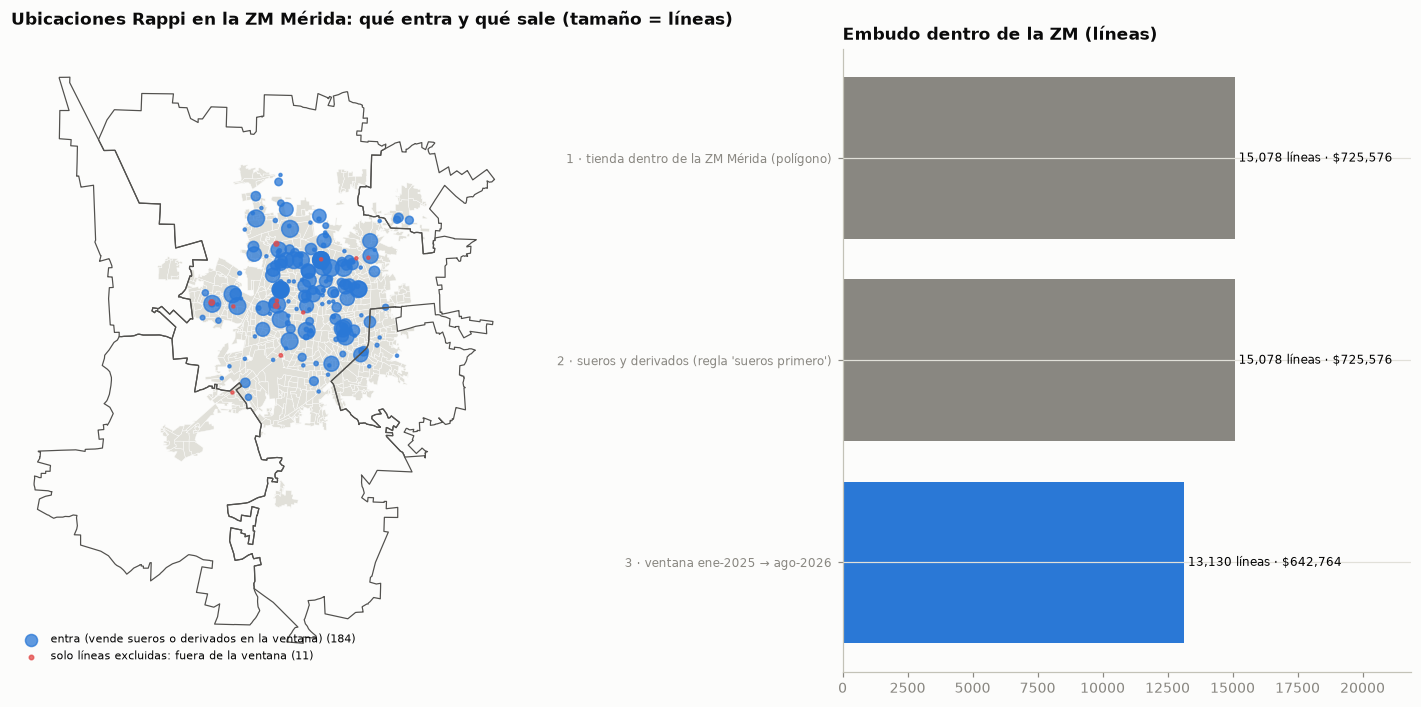

In [5]:
cand["motivo"] = np.select(
    [~con_xy, ~cand.en_zm, cand.subcategoria.isna(), ~cand.fecha.between(ini, fin, inclusive="left")],
    ["sin coordenadas", "fuera de la ZM", cand.regla, "fuera de la ventana"], "entra")
u = cand[cand.motivo.eq("entra")].copy()
u["subcategoria"] = u.subcategoria.astype(str)


def paso(nombre, df):
    return {"paso": nombre, "líneas": len(df), "pedidos": df.order_code.nunique(), "venta MXN": df.beverage_sales.sum(),
            "store_id": df.store_id.nunique()}


embudo = pd.DataFrame([
    paso("0 · archivo nacional", nac),
    paso(f"1 · tienda dentro de la {C.ZM_NOMBRE} (polígono)", zmx),
    paso("2 · sueros y derivados (regla 'sueros primero')", zmx[zmx.subcategoria.notna()]),
    paso(f"3 · ventana {mes_txt(ini)} → {mes_txt(cierre)}", u)])
embudo["% de las líneas del paso anterior"] = (embudo.líneas / embudo.líneas.shift() * 100).round(2)
display(embudo)
excluidas = (cand[cand.etiqueta_ciudad | cand.en_zm].groupby("motivo")
             .agg(líneas=("order_code", "size"), venta_MXN=("beverage_sales", "sum"), tiendas=("store_id", "nunique"),
                  ejemplos=("Product_Brand", lambda s: ", ".join(s.value_counts().index[:3].astype(str)))).sort_values("líneas", ascending=False))
display(excluidas)

# mapa de QA: cada ubicación Rappi con su estado (entra si alguna línea entra)
loc = (cand[con_xy].assign(entra=cand.motivo.eq("entra"))
       .groupby(["store_lat", "store_lng"]).agg(entra=("entra", "any"), motivo=("motivo", lambda s: s.value_counts().index[0]),
                                                líneas=("order_code", "size")).reset_index())
loc["estado"] = np.where(loc.entra, "entra (vende sueros o derivados en la ventana)", "solo líneas excluidas: " + loc.motivo)
gl = gpd.GeoDataFrame(loc, geometry=gpd.points_from_xy(loc.store_lng, loc.store_lat), crs=4326).to_crs(mun.crs)
fig, ax = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.25, 1]})
agebs.plot(ax=ax[0], color=eda.GRID, edgecolor=eda.FONDO, lw=0.3)
zm.boundary.plot(ax=ax[0], color=eda.TINTA_2, lw=0.8)
colores = dict(zip(sorted(gl.estado.unique(), key=lambda e: not e.startswith("entra")), [AZUL, ROJO, AMBAR, MORADO, NARANJA, ROSA, VERDE2]))
for e, g in gl.groupby("estado"):
    g.plot(ax=ax[0], color=colores[e], markersize=np.clip(g.líneas, 4, 120), alpha=0.75, label=f"{e} ({len(g)})")
ax[0].set_axis_off()
ax[0].legend(loc="lower left", fontsize=7)
ax[0].set_title(f"Ubicaciones Rappi en la {C.ZM_NOMBRE}: qué entra y qué sale (tamaño = líneas)")
e2 = embudo.iloc[1:]
ax[1].barh(e2.paso, e2.líneas, color=[eda.MUTED] * (len(e2) - 1) + [AZUL])
for k, (n_, v_) in enumerate(zip(e2.líneas, e2["venta MXN"])):
    ax[1].text(n_, k, f" {n_:,} líneas · ${v_:,.0f}", va="center", fontsize=8)
ax[1].invert_yaxis()
ax[1].set_title("Embudo dentro de la ZM (líneas)")
ax[1].tick_params(axis="y", labelsize=8)
ax[1].set_xlim(0, e2.líneas.max() * 1.45)
plt.tight_layout(); plt.show()

**Lectura:** si todas las líneas dentro de la ZM traen la etiqueta de la ciudad y ninguna con la etiqueta cae fuera (salvo
las que no tienen coordenadas), la etiqueta y el polígono coinciden y el universo es el correcto. De producto solo sale lo
que no es suero ni derivado (Vitamin Water, refrescos); las marcas sin subcategoría **entran** porque pueden ser sueros.

## 2. Grano, llaves, duplicados y tiendas físicas

* **Llave del pedido:** cada `order_code` debe tener una sola tienda, una sola fecha-hora y un solo usuario.
* **Duplicados:** las líneas idénticas pueden ser un error de carga o dos productos distintos que se ven iguales. Los
  productos Coca-Cola traen su código de barras: ahí una línea repetida sí sería error, y su tasa sirve de **línea base**.
  Los competidores vienen anonimizados a nivel marca: dos sabores de la misma marca al mismo precio en un pedido quedan
  idénticos. Si la tasa de los competidores es mucho mayor que la base, el exceso es anonimización, no error.
* **Tienda física:** Rappi da un `store_id` por "tienda virtual" (…_Express, …_Super, …_Pharma, …_Licores): se agrupan las
  coordenadas a ≤ 25 m en una tienda física.

In [6]:
g_ped = u.groupby("order_code").agg(tiendas=("store_id", "nunique"), horas=("fecha", "nunique"), usuarios=("user_code", "nunique"))
LLAVE = (f"{len(g_ped):,} pedidos · con más de una tienda: {(g_ped.tiendas > 1).sum()} · más de una fecha-hora: {(g_ped.horas > 1).sum()} "
         f"· más de un usuario: {(g_ped.usuarios > 1).sum()}")
print("Llave del pedido:", LLAVE)
print(f"Negativos: importe {(u.beverage_sales < 0).sum()} · unidades {(u.beverage_units < 0).sum()} | ceros: importe {(u.beverage_sales == 0).sum()} "
      f"· unidades {(u.beverage_units == 0).sum()}")
COLS_ORIG = [c for c in R.COLUMNAS if c in u.columns]
u["duplicada"] = u.duplicated(COLS_ORIG, keep=False)
dups = u.groupby("Product_Maker_Standard").agg(líneas=("duplicada", "size"), en_líneas_idénticas=("duplicada", "sum"))
dups["%"] = dups.en_líneas_idénticas / dups.líneas * 100
t_dup = pd.crosstab(u.Product_Maker_Standard, u.duplicada)
# sin las líneas BRAND_x casi no quedan competidores (solo marca "No disponible"): las comparaciones contra ellos no aplican
N_COMP = int(u.Product_Maker_Standard.eq("COMPETITOR").sum())
HAY_COMP = N_COMP >= 20 and t_dup.shape == (2, 2)
SIN_COMP = f"no aplica: sin las líneas BRAND_x quedan {N_COMP} líneas de competidores"
DUPLICADOS = ((f"Líneas idénticas: Coca-Cola {dups.loc['COCA-COLA', '%']:.1f}% (línea base, tienen código de barras) vs competidores "
               f"{dups.loc['COMPETITOR', '%']:.1f}% (anonimizados); V de Cramér = {eda.cramer_v(t_dup):.2f}, χ² p = "
               f"{stats.chi2_contingency(t_dup)[1]:.0e}. Se conservan: el exceso de los competidores es anonimización.") if HAY_COMP else
              f"Líneas idénticas: Coca-Cola {dups.loc['COCA-COLA', '%']:.1f}% (tienen código de barras; se conservan); competidores {SIN_COMP}.")
display(dups)
print(DUPLICADOS)

xy = u[["store_lat", "store_lng"]].drop_duplicates().reset_index(drop=True)
xy["tienda_fisica"] = R.tiendas_fisicas(xy.store_lat, xy.store_lng, 25)
u = u.merge(xy, on=["store_lat", "store_lng"], how="left")
por_tienda = u.groupby("tienda_fisica").agg(store_ids=("store_id", "nunique"), coordenadas=("store_lat", "nunique"))
multi = u.groupby("store_id").tienda_fisica.nunique()
TIENDAS = (f"{u.store_id.nunique()} store_id y {len(xy)} coordenadas → {u.tienda_fisica.nunique()} tiendas físicas "
           f"(mediana {por_tienda.store_ids.median():.0f} store_id por tienda, máx. {por_tienda.store_ids.max()}); "
           f"{(multi > 1).sum()} store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).")
print(TIENDAS)
ej = u[u.tienda_fisica.eq(por_tienda.store_ids.idxmax())].groupby(["store_id", "store_name", "vertical"], dropna=False).size().rename("líneas")
display(ej.to_frame().head(15))

Llave del pedido: 11,771 pedidos · con más de una tienda: 0 · más de una fecha-hora: 0 · más de un usuario: 0
Negativos: importe 0 · unidades 0 | ceros: importe 0 · unidades 0


,líneas,en_líneas_idénticas,%
Product_Maker_Standard,,,
COCA-COLA,13130,124,0.944


Líneas idénticas: Coca-Cola 0.9% (tienen código de barras; se conservan); competidores no aplica: sin las líneas BRAND_x quedan 0 líneas de competidores.
453 store_id y 184 coordenadas → 172 tiendas físicas (mediana 2 store_id por tienda, máx. 28); 0 store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).


,,,líneas
store_id,store_name,vertical,
1923720814,"Turbo, El Rosario",TURBO,2457
1923720876,"Turbo, El Rosario",TURBO,78
1923720878,"Turbo, El Rosario",TURBO,16
1923720879,"Turbo, El Rosario",TURBO,17
1923720883,"Turbo, El Rosario",TURBO,18
1923720884,"Turbo, El Rosario",TURBO,20
1930044341,"Turbo, El Rosario",TURBO,43
1930097088,"Turbo Farma, El Rosario",TURBO,13
1930108871,"Turbo Farma, El Rosario",TURBO,10


## 3. Faltantes y su mecanismo

Antes de imputar hay que saber **por qué** falta cada dato. Si falta solo en un tipo de fila (por diseño de la
exportación), no es azar (MNAR/MAR) y no se imputa: se analiza donde existe.

In [7]:
nulos = u[COLS_ORIG].isna().mean().mul(100).round(1)
display(nulos[nulos > 0].to_frame("% líneas sin dato"))
t_usr = pd.crosstab(u.Product_Maker_Standard, u.user_code.isna().rename("sin usuario"))
t_prod = pd.crosstab(u.Product_Maker_Standard, u.Product_name.isna().rename("sin nombre de producto"))
display(t_usr)
edad = u.age.where(u.age >= 15)                              # 0-14 años no son compradores válidos: se tratan como faltantes
FALTANTES = ((f"Usuario y producto faltan exactamente en los competidores (V de Cramér usuario = {eda.cramer_v(t_usr):.2f}, "
              f"producto = {eda.cramer_v(t_prod):.2f}): anonimización por diseño. " if HAY_COMP and t_usr.shape == (2, 2) and t_prod.shape == (2, 2)
              else f"Usuario y producto vs competidores: {SIN_COMP}. ") +
             f"Edad: {u.age.isna().mean():.0%} sin dato y "
             f"{(u.age < 15).mean():.1%} con edad < 15 (inválida); género 'O' = {(u.gender == 'O').mean():.0%}.")
print(FALTANTES)

,% líneas sin dato
State,100.000
age,37.500


sin usuario,False
Product_Maker_Standard,
COCA-COLA,13130


Usuario y producto vs competidores: no aplica: sin las líneas BRAND_x quedan 0 líneas de competidores. Edad: 37% sin dato y 0.0% con edad < 15 (inválida); género 'O' = 19%.


## 4. Univariado, colas y concentración

Tres niveles: **línea** (importe, unidades, precio unitario), **pedido** (importe y unidades de sueros e hidratación por
pedido) y **tienda física** (venta por mes de vida en la ventana, como `cajas_mes_vida` en el 00: venta / meses desde su
primer mes con venta hasta el cierre, para no premiar a las que entraron tarde ni castigar a las que salieron).
La "unidad" de Rappi es el artículo vendido: una caja de 12 o 24 botellas cuenta 1 (empaque múltiple, sobre todo en Costco).

,n,media,mediana,mediana_IC95,MAD_n,p99,max,asimetria,gini,hill_alpha,cuota_top20%,lectura
variable,,,,,,,,,,,,
beverage_sales,13130,48.954,36.745,"[35.90, 37.00]",11.483,186.000,962.500,6.290,0.298,3.031,40.501,asimetrica: usar log1p
beverage_units,13130,1.556,1.000,"[1.00, 1.00]",0.000,6.000,30.000,7.035,0.278,2.606,40.295,asimetrica: usar log1p
precio_unitario,13130,32.152,33.000,"[33.00, 33.00]",6.687,45.000,116.000,0.758,0.111,11.676,25.341,aprox. simetrica
importe,11771,54.606,38.000,"[37.90, 38.90]",14.529,233.400,"1,347.500",6.980,0.335,2.870,43.084,asimetrica: usar log1p
unidades,11771,1.735,1.000,"[1.00, 1.00]",0.000,8.000,35.000,6.958,0.324,2.187,43.477,asimetrica: usar log1p
líneas,11771,1.115,1.000,"[1.00, 1.00]",0.000,3.000,11.000,5.559,0.096,6.065,28.279,asimetrica: usar log1p
venta_mes,172,208.747,66.497,"[52.50, 83.37]",71.288,"3,231.460","7,721.367",8.405,0.749,1.087,77.228,cola muy pesada: usar mediana/MAD y log1p
venta_sueros_mes,172,28.654,3.984,"[2.35, 7.25]",5.907,483.686,"1,703.279",9.378,0.865,0.919,80.726,cola muy pesada: usar mediana/MAD y log1p
pedidos_mes,172,3.825,1.411,"[1.00, 1.63]",1.510,57.802,148.300,8.651,0.734,1.327,75.225,cola muy pesada: usar mediana/MAD y log1p


,familia,parametros,logL,AIC,KS_D,ΔAIC,nivel
0,lognorm,"[0.538, 0.0, 45.5094]","-54,346.060","108,696.120",0.165,0.000,pedido (importe)
1,gamma,"[2.8999, 0.0, 18.8304]","-56,048.384","112,100.769",0.192,"3,404.649",pedido (importe)
2,weibull_min,"[1.4348, 0.0, 60.9825]","-57,404.955","114,813.911",0.188,"6,117.791",pedido (importe)
3,expon,"[0.0, 54.6058]","-58,856.642","117,715.285",0.312,"9,019.165",pedido (importe)


,familia,parametros,logL,AIC,KS_D,ΔAIC,nivel
0,lognorm,"[1.3365, 0.0, 63.0435]","-1,006.685","2,017.370",0.052,0.000,tienda (venta/mes)
1,weibull_min,"[0.6506, 0.0, 125.5134]","-1,035.727","2,075.454",0.116,58.085,tienda (venta/mes)
2,gamma,"[0.5263, 0.0, 396.6071]","-1,059.601","2,123.201",0.190,105.831,tienda (venta/mes)
3,expon,"[0.0, 208.7469]","-1,090.673","2,183.346",0.268,165.976,tienda (venta/mes)


Empaques múltiples (precio por 'unidad' > $150): 0 líneas (0.0%) y 0.0% de la venta. Box-Cox λ del importe por pedido = -0.79.


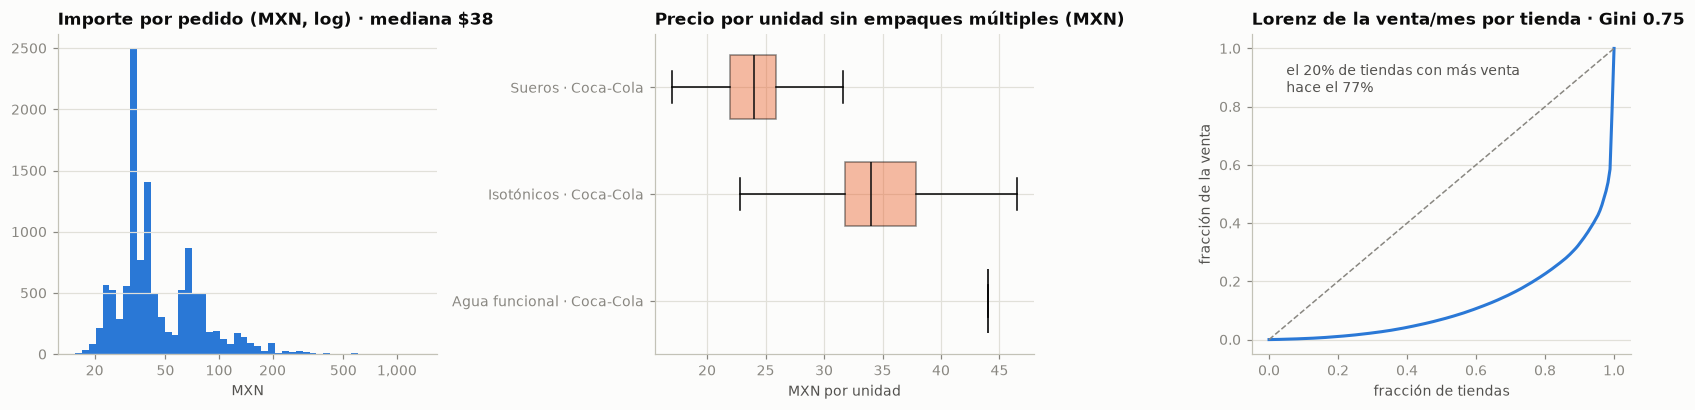

In [8]:
u["precio_unitario"] = u.beverage_sales / u.beverage_units
u["multiempaque"] = u.precio_unitario > 150                  # un suero o isotónico individual cuesta 20-50 MXN
u["mes_n"] = u.fecha.dt.year * 12 + u.fecha.dt.month - 1
u["mes"] = u.fecha.dt.strftime("%Y-%m")
MES_FIN = cierre.year * 12 + cierre.month - 1
cc = u.Product_Maker_Standard.eq("COCA-COLA")
ped = u.assign(cc=cc, suero=u.subcategoria.eq(SUEROS), iso=u.subcategoria.eq(ISOTONICOS)).groupby("order_code").agg(
    tienda=("tienda_fisica", "first"), fecha=("fecha", "first"), usuario=("user_code", "first"), pago=("User_Attribute_1", "first"),
    importe=("beverage_sales", "sum"), unidades=("beverage_units", "sum"), líneas=("store_id", "size"),
    con_coca=("cc", "any"), solo_coca=("cc", "all"), con_suero=("suero", "any"), con_isotonico=("iso", "any"))
ped["con_competidor"] = ~ped.solo_coca


def moda(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else np.nan


tf = u.assign(cc_venta=u.beverage_sales.where(cc, 0), s_venta=u.beverage_sales.where(u.subcategoria.eq(SUEROS), 0),
              s_ped=u.order_code.where(u.subcategoria.eq(SUEROS))).groupby("tienda_fisica").agg(
    nombre=("store_name", moda), cadena=("store_group_name", moda), vertical=("vertical", moda), municipio=("municipio", moda),
    lat=("store_lat", "median"), lon=("store_lng", "median"), store_ids=("store_id", "nunique"),
    venta=("beverage_sales", "sum"), venta_sueros=("s_venta", "sum"), venta_coca=("cc_venta", "sum"), unidades=("beverage_units", "sum"),
    pedidos=("order_code", "nunique"), pedidos_sueros=("s_ped", "nunique"), líneas=("store_id", "size"),
    meses_activos=("mes_n", "nunique"), primer_mes=("mes_n", "min"), ultimo_mes=("mes_n", "max"))
tf["meses_vida"] = MES_FIN - tf.primer_mes + 1
tf["venta_mes"] = tf.venta / tf.meses_vida
tf["venta_sueros_mes"] = tf.venta_sueros / tf.meses_vida
tf["pedidos_mes"] = tf.pedidos / tf.meses_vida
tf["unidades_mes"] = tf.unidades / tf.meses_vida
tf["tasa_actividad"] = tf.meses_activos / tf.meses_vida
tf["recencia_meses"] = MES_FIN - tf.ultimo_mes
tf["% sueros"] = tf.venta_sueros / tf.venta * 100
tf["% Coca-Cola"] = tf.venta_coca / tf.venta * 100
TIPO = {"TURBO": "Turbo (dark store)", "SUPER": "Supermercado", "EXPRESS": "Conveniencia", "PHARMACY": "Farmacia"}
tf["tipo"] = np.where(tf.cadena.eq("Turbo"), TIPO["TURBO"], tf.vertical.map(TIPO).fillna("Otro"))
uni = pd.concat([eda.univariado(u, ["beverage_sales", "beverage_units", "precio_unitario"]),
                 eda.univariado(ped, ["importe", "unidades", "líneas"]),
                 eda.univariado(tf, ["venta_mes", "venta_sueros_mes", "pedidos_mes", "meses_activos", "tasa_actividad"])])
display(uni[["n", "media", "mediana", "mediana_IC95", "MAD_n", "p99", "max", "asimetria", "gini", "hill_alpha", "cuota_top20%", "lectura"]])
aj_ped = eda.ajuste_distribuciones(ped.importe.to_numpy())
aj_tf = eda.ajuste_distribuciones(tf.venta_mes.to_numpy())
display(aj_ped.assign(nivel="pedido (importe)"))
display(aj_tf.assign(nivel="tienda (venta/mes)"))
lam = stats.boxcox(ped.importe.to_numpy())[1]
MULTI = (f"Empaques múltiples (precio por 'unidad' > $150): {u.multiempaque.sum()} líneas ({u.multiempaque.mean():.1%}) y "
         f"{u.beverage_sales[u.multiempaque].sum() / u.beverage_sales.sum():.1%} de la venta"
         + (f", sobre todo en {', '.join(u.store_group_name[u.multiempaque].value_counts().index[:2].astype(str))}" if u.multiempaque.any() else "")
         + f". Box-Cox λ del importe por pedido = {lam:.2f}.")
print(MULTI)

fx, fy = eda.lorenz(tf.venta_mes.to_numpy())
top20 = 1 - np.interp(0.8, fx, fy)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(np.log10(ped.importe), bins=50, color=AZUL)
ax[0].set_xticks(np.log10([20, 50, 100, 200, 500, 1000]), ["20", "50", "100", "200", "500", "1,000"])
ax[0].set(title=f"Importe por pedido (MXN, log) · mediana ${ped.importe.median():.0f}", xlabel="MXN")
grupos = list(u[~u.multiempaque].groupby(["subcategoria", "Product_Maker_Standard"]))
for k, ((s, m), g) in enumerate(grupos):
    ax[1].boxplot(g.precio_unitario, positions=[k], widths=0.6, orientation="horizontal", showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor=NARANJA if m == "COCA-COLA" else AZUL, alpha=0.45), medianprops=dict(color=eda.TINTA))
ax[1].set_yticks(range(len(grupos)), [f"{s.split(' (')[0]} · {'Coca-Cola' if m == 'COCA-COLA' else 'competidor'}" for (s, m), _ in grupos])
ax[1].set(title="Precio por unidad sin empaques múltiples (MXN)", xlabel="MXN por unidad")
ax[1].grid(axis="x", color=eda.GRID)
ax[2].plot(fx, fy, color=AZUL)
ax[2].plot([0, 1], [0, 1], color=eda.MUTED, lw=1, ls="--")
ax[2].set(title=f"Lorenz de la venta/mes por tienda · Gini {eda.gini(tf.venta_mes):.2f}", xlabel="fracción de tiendas", ylabel="fracción de la venta")
ax[2].text(0.05, 0.85, f"el 20% de tiendas con más venta\nhace el {top20:.0%}", color=eda.TINTA_2)
plt.tight_layout(); plt.show()

## 5. Tiempo y calendario

Serie diaria de toda la ZM (los días sin líneas se rellenan con 0 para detectar huecos de captura). Pruebas: crecimiento
año contra año en los **mismos meses** (ene–ago 2025 vs ene–ago 2026) con IC por **bootstrap de semanas** (los días de una
semana no son independientes), total y por fabricante; estacionalidad por mes calendario (Kruskal-Wallis, ε²) y temporada
de calor (abr–jun) contra la fresca (nov–feb) con δ de Cliff; día de la semana y quincena (días 15–17 y 30–2).

Días de la ventana: 608 | días sin ninguna línea en la ZM: 0 (huecos de captura)


,prueba,efecto,detalle
0,Crecimiento ene–ago 2026 vs 2025 · venta total (Coca-Cola),+8.0%,"IC95 bootstrap de semanas [-4.5%, +22.8%]"
1,Crecimiento ene–ago 2026 vs 2025 · pedidos,-4.6%,"IC95 bootstrap de semanas [-14.0%, +5.6%]"
2,Estacionalidad por mes (Kruskal-Wallis),ε² = 0.249,"IC95 [0.210, 0.317] · q = 3.3e-28"
3,"Calor (abr–jun) vs fresca (nov–feb), venta diaria",δ = +0.49,"mediana $1,151 vs $769 · p = 1.5e-15"
4,Día de la semana (Kruskal-Wallis),ε² = 0.099,"IC95 [0.064, 0.163] · fin de semana vs entre semana δ = +0.33"
5,Quincena (días 15–17 y 30–2) vs resto,δ = +0.04,p = 0.54


,venta,pedidos,unidades,tiendas,usuarios,ticket,% sueros,% Coca-Cola
mes,,,,,,,,
2025-01,"19,335.200",447,620.000,77,337,43.300,12.200,100.000
2025-02,"22,534.800",486,667.000,72,375,46.400,9.800,100.000
2025-03,"28,475.700",569,852.000,73,407,50.000,9.100,100.000
2025-04,"26,180.400",494,808.000,70,376,53.000,11.500,100.000
2025-05,"39,799.900",783,"1,285.000",84,579,50.800,14.900,100.000
2025-06,"32,962.800",641,"1,116.000",78,481,51.400,14.200,100.000
2025-07,"33,112.300",652,"1,094.000",77,471,50.800,15.400,100.000
2025-08,"42,337.900",772,"1,407.000",82,546,54.800,11.200,100.000
2025-09,"35,755.800",580,"1,201.000",71,422,61.600,9.700,100.000


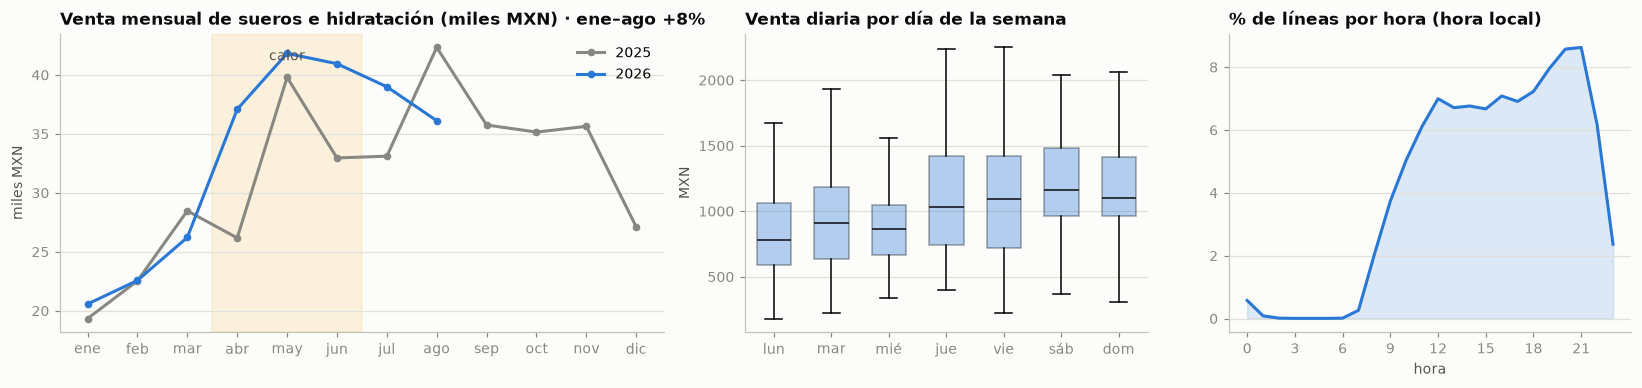

In [9]:
dia = (u.groupby(u.fecha.dt.normalize()).agg(venta=("beverage_sales", "sum"), pedidos=("order_code", "nunique"),
                                             venta_cc=("beverage_sales", lambda s: s[cc.loc[s.index]].sum()))
       .reindex(pd.date_range(ini, cierre, freq="D"), fill_value=0))
dia["mes_cal"] = dia.index.month
dia["dow"] = dia.index.dayofweek
dia["semana"] = (dia.index - ini).days // 7
dia["venta_comp"] = dia.venta - dia.venta_cc
print(f"Días de la ventana: {len(dia)} | días sin ninguna línea en la ZM: {(dia.pedidos == 0).sum()} (huecos de captura)")
mensual = u.groupby("mes").agg(venta=("beverage_sales", "sum"), pedidos=("order_code", "nunique"), unidades=("beverage_units", "sum"),
                               tiendas=("tienda_fisica", "nunique"), usuarios=("user_code", "nunique"))
mensual["ticket"] = mensual.venta / mensual.pedidos
mensual["% sueros"] = u.assign(v=u.beverage_sales.where(u.subcategoria.eq(SUEROS), 0)).groupby("mes").v.sum() / mensual.venta * 100
mensual["% Coca-Cola"] = u.assign(v=u.beverage_sales.where(cc, 0)).groupby("mes").v.sum() / mensual.venta * 100

a1, a2 = dia[(dia.index >= "2025-01-01") & (dia.index < "2025-09-01")], dia[(dia.index >= "2026-01-01") & (dia.index < "2026-09-01")]


def yoy(col):
    sa, sb = a1.groupby("semana").indices, a2.groupby("semana").indices
    xa, xb = a1[col].to_numpy(), a2[col].to_numpy()
    bs = [xb[np.concatenate([sb[k] for k in rng.choice(list(sb), len(sb))])].mean() /
          xa[np.concatenate([sa[k] for k in rng.choice(list(sa), len(sa))])].mean() - 1 for _ in range(2000)]
    return xb.sum() / xa.sum() - 1, *np.quantile(bs, [0.025, 0.975])


SERIES_CREC = [("venta", "venta total"), ("venta_cc", "Coca-Cola"), ("venta_comp", "competidores"), ("pedidos", "pedidos")]
if not HAY_COMP:                                     # sin BRAND_x: venta total = Coca-Cola y no hay competidores
    SERIES_CREC = [("venta", "venta total (Coca-Cola)"), ("pedidos", "pedidos")]
crec = {c: yoy(c) for c, _ in SERIES_CREC}
calor, fresca = dia[dia.mes_cal.isin([4, 5, 6])].venta, dia[dia.mes_cal.isin([11, 12, 1, 2])].venta
d_calor = eda.cliff_delta(calor, fresca)
quin = dia.index.day.isin([15, 16, 17, 30, 31, 1, 2])
d_quin = eda.cliff_delta(dia.venta[quin], dia.venta[~quin])
finde = dia.dow >= 5
d_finde = eda.cliff_delta(dia.venta[finde], dia.venta[~finde])
cal = eda.efecto_categorico(dia.assign(mes_cal=dia.mes_cal.astype(str), dow=dia.dow.astype(str)), ["mes_cal", "dow"], "venta").set_index("variable")
calendario = pd.DataFrame([
    *[(f"Crecimiento ene–ago 2026 vs 2025 · {n_}", f"{crec[c][0]:+.1%}", f"IC95 bootstrap de semanas [{crec[c][1]:+.1%}, {crec[c][2]:+.1%}]")
      for c, n_ in SERIES_CREC],
    ("Estacionalidad por mes (Kruskal-Wallis)", f"ε² = {cal.loc['mes_cal', 'epsilon2']:.3f}", f"IC95 {cal.loc['mes_cal', 'IC95']} · q = {cal.loc['mes_cal', 'q_BH']:.1e}"),
    ("Calor (abr–jun) vs fresca (nov–feb), venta diaria", f"δ = {d_calor:+.2f}",
     f"mediana ${calor.median():,.0f} vs ${fresca.median():,.0f} · p = {stats.mannwhitneyu(calor, fresca).pvalue:.1e}"),
    ("Día de la semana (Kruskal-Wallis)", f"ε² = {cal.loc['dow', 'epsilon2']:.3f}", f"IC95 {cal.loc['dow', 'IC95']} · fin de semana vs entre semana δ = {d_finde:+.2f}"),
    ("Quincena (días 15–17 y 30–2) vs resto", f"δ = {d_quin:+.2f}", f"p = {stats.mannwhitneyu(dia.venta[quin], dia.venta[~quin]).pvalue:.2f}"),
], columns=["prueba", "efecto", "detalle"])
with pd.option_context("display.max_colwidth", None):
    display(calendario)
display(mensual.round(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), gridspec_kw={"width_ratios": [1.5, 1, 1]})
for anio, col in [("2025", eda.MUTED), ("2026", AZUL)]:
    s = mensual.venta[mensual.index.str.startswith(anio)]
    ax[0].plot([int(m[5:]) for m in s.index], s.values / 1000, "o-", color=col, label=anio, ms=4)
ax[0].set_xticks(range(1, 13), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
ax[0].axvspan(3.5, 6.5, color=AMBAR, alpha=0.12)
ax[0].text(5, ax[0].get_ylim()[1] * 0.97, "calor", ha="center", va="top", color=eda.TINTA_2)
ax[0].set(title=f"Venta mensual de sueros e hidratación (miles MXN) · ene–ago {crec['venta'][0]:+.0%}", ylabel="miles MXN")
ax[0].legend()
ax[1].boxplot([dia.venta[dia.dow == k] for k in range(7)], widths=0.6, showfliers=False, patch_artist=True,
              boxprops=dict(facecolor=AZUL, alpha=0.35), medianprops=dict(color=eda.TINTA))
ax[1].set_xticks(range(1, 8), ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
ax[1].set(title="Venta diaria por día de la semana", ylabel="MXN")
ax[2].plot(hora.index, hora.iloc[:, 0], color=AZUL)
ax[2].fill_between(hora.index, hora.iloc[:, 0], color=AZUL, alpha=0.15)
ax[2].set(title="% de líneas por hora (hora local)", xlabel="hora", xticks=range(0, 24, 3))
plt.tight_layout(); plt.show()

## 6. Fabricante, marca y precio

`Product_Maker_Standard` separa **Coca-Cola** (el sistema de Bepensa: Powerade, Flashlyte) de los **competidores**.
Participación por valor, unidades y pedidos; su tendencia mensual (τ de Kendall contra el tiempo) y el precio por unidad
de Coca-Cola contra competidores dentro de cada subcategoría, sin empaques múltiples (Mann-Whitney, δ de Cliff, q de BH).
No se estima elasticidad: los competidores no traen SKU y no hay marcas de promoción (el precio cambia con el empaque).

In [10]:
fab = u.groupby("Product_Maker_Standard").agg(venta=("beverage_sales", "sum"), unidades=("beverage_units", "sum"),
                                              líneas=("store_id", "size"), pedidos=("order_code", "nunique"))
fab_pct = (fab / fab.sum() * 100).add_prefix("% ")
sub_fab = pd.crosstab(u.subcategoria, u.Product_Maker_Standard, values=u.beverage_sales, aggfunc="sum", margins=True, normalize="index") * 100
sub_tot = u.groupby("subcategoria").beverage_sales.sum() / u.beverage_sales.sum() * 100
tipo_fab = pd.crosstab(u.tienda_fisica.map(tf.tipo), u.Product_Maker_Standard, values=u.beverage_sales, aggfunc="sum", normalize="index") * 100
tau_cc = stats.kendalltau(np.arange(len(mensual)), mensual["% Coca-Cola"])
display(pd.concat([fab, fab_pct], axis=1).round(1))
display(sub_fab.round(1).join(sub_tot.rename("% de la venta total")))
display(tipo_fab.round(1).rename_axis("tipo de tienda"))
marcas_top = (u.groupby(["Product_Brand", "Product_Maker_Standard", "subcategoria"])
              .agg(venta=("beverage_sales", "sum"), líneas=("store_id", "size"), precio_mediano=("precio_unitario", "median"),
                   multiempaque_pct=("multiempaque", "mean"), tiendas=("tienda_fisica", "nunique")).reset_index().sort_values("venta", ascending=False))
marcas_top["% venta"] = marcas_top.venta / marcas_top.venta.sum() * 100
marcas_top["multiempaque_pct"] *= 100
display(marcas_top.head(12).round(1))
precio = []
for s, g in u[~u.multiempaque].groupby("subcategoria"):
    a, b = g.precio_unitario[g.Product_Maker_Standard.eq("COCA-COLA")], g.precio_unitario[g.Product_Maker_Standard.eq("COMPETITOR")]
    if len(a) >= 20 and len(b) >= 20:
        precio.append({"subcategoria": s, "n Coca-Cola": len(a), "n competidor": len(b), "mediana Coca-Cola": a.median(),
                       "mediana competidor": b.median(), "δ Cliff (CC vs comp)": eda.cliff_delta(a, b), "p": stats.mannwhitneyu(a, b).pvalue})
precio = pd.DataFrame(precio, columns=["subcategoria", "n Coca-Cola", "n competidor", "mediana Coca-Cola", "mediana competidor",
                                       "δ Cliff (CC vs comp)", "p"])
precio["q_BH"] = stats.false_discovery_control(precio.p, method="bh") if len(precio) else []
if precio.empty:
    precio = pd.DataFrame({"nota": [f"Precio Coca-Cola vs competidor: {SIN_COMP}"]})
display(precio.round(3))
MARCAS = (f"Sueros = {sub_tot.get(SUEROS, 0):.0f}% de la venta, isotónicos {sub_tot.get(ISOTONICOS, 0):.0f}%, sin subcategoría "
          f"{sub_tot.get(R.SIN_SUB, 0):.1f}%. " +
          (f"Coca-Cola hace {fab_pct.loc['COCA-COLA', '% venta']:.0f}% del valor (sueros {sub_fab.loc[SUEROS, 'COCA-COLA']:.0f}%, "
           f"isotónicos {sub_fab.loc[ISOTONICOS, 'COCA-COLA']:.0f}%); tendencia de su participación mensual τ = {tau_cc[0]:+.2f} "
           f"(p = {tau_cc[1]:.2f})." if HAY_COMP else
           "Sin las líneas BRAND_x la venta es de Coca-Cola: no se mide participación contra competidores. Por marca: " +
           ", ".join(f"{m} {v:.0f}%" for m, v in (u.groupby('Product_Brand').beverage_sales.sum() / u.beverage_sales.sum() * 100)
                     .sort_values(ascending=False).head(4).items()) + "."))
print(MARCAS)

,venta,unidades,líneas,pedidos,% venta,% unidades,% líneas,% pedidos
Product_Maker_Standard,,,,,,,,
COCA-COLA,"642,764.500","20,427.000",13130,11771,100.000,100.000,100.000,100.000


,COCA-COLA,% de la venta total
subcategoria,,
Agua funcional (Vitamin Water),100.000,0.135
Isotónicos (derivados),100.000,85.546
Sueros (hidratantes),100.000,14.320
All,100.000,NaN


Product_Maker_Standard,COCA-COLA
tipo de tienda,
Conveniencia,100.000
Farmacia,100.000
Supermercado,100.000
Turbo (dark store),100.000


,Product_Brand,Product_Maker_Standard,subcategoria,venta,líneas,precio_mediano,multiempaque_pct,tiendas,% venta
1,Powerade,COCA-COLA,Isotónicos (derivados),"549,856.200",10873,34.000,0.000,171,85.500
0,Flashlyte,COCA-COLA,Sueros (hidratantes),"92,042.800",2241,24.000,0.000,105,14.300
2,Vitamin Water,COCA-COLA,Agua funcional (Vitamin Water),865.500,16,44.000,0.000,7,0.100


,nota
0,Precio Coca-Cola vs competidor: no aplica: sin...


Sueros = 14% de la venta, isotónicos 86%, sin subcategoría 0.0%. Sin las líneas BRAND_x la venta es de Coca-Cola: no se mide participación contra competidores. Por marca: Powerade 86%, Flashlyte 14%, Vitamin Water 0%.


## 7. Canasta y clientes

* **Canasta:** líneas y unidades por pedido; co-compra de Coca-Cola con competidor y de suero con isotónico en el mismo
  pedido: soporte, **lift** = P(A y B) / (P(A)·P(B)) y prueba exacta de Fisher (lift < 1 = se sustituyen; > 1 = se complementan).
* **Clientes:** solo las líneas Coca-Cola traen usuario, así que la recompra se mide en compradores de Coca-Cola:
  frecuencia, índice de dispersión (varianza / media; > 1 = sobredispersión frente a Poisson), % que recompra, recencia
  al cierre e independencia frecuencia–ticket (supuesto Gamma-Gamma).
* **Pago:** mezcla de medios de pago por tienda. El % de Apple Pay y de efectivo es una señal digital de NSE (como el %
  iOS de AltScore) que el 06 contrasta con el NSE de INEGI alrededor de cada tienda.

In [11]:
def co_compra(a, b):
    t = pd.crosstab(a, b).reindex(index=[False, True], columns=[False, True], fill_value=0)
    ab = (a & b).mean()
    return {"soporte A": a.mean(), "soporte B": b.mean(), "soporte A y B": ab, "lift": ab / (a.mean() * b.mean()),
            "p Fisher": stats.fisher_exact(t.to_numpy())[1]}


canasta = pd.DataFrame({**({"Coca-Cola × competidor": co_compra(ped.con_coca, ped.con_competidor)} if HAY_COMP else {}),
                        "suero × isotónico": co_compra(ped.con_suero, ped.con_isotonico)}).T
display(canasta.round(4))
print(f"Líneas por pedido: {ped.líneas.value_counts(normalize=True).mul(100).round(1).head(4).to_dict()} (%)")
cli = (ped.dropna(subset=["usuario"]).groupby("usuario")
       .agg(pedidos=("importe", "size"), gasto=("importe", "sum"), ticket=("importe", "mean"), ultima=("fecha", "max")))
disp = cli.pedidos.var() / cli.pedidos.mean()
chi_disp = ((cli.pedidos - cli.pedidos.mean()) ** 2).sum() / cli.pedidos.mean()
rep = cli[cli.pedidos >= 2]
gg = stats.spearmanr(rep.pedidos, rep.ticket)
CLIENTES = (f"{len(cli):,} compradores de Coca-Cola: {(cli.pedidos >= 2).mean():.0%} recompra; pedidos por comprador mediana "
            f"{cli.pedidos.median():.0f}, p90 {cli.pedidos.quantile(0.9):.0f}; dispersión var/media = {disp:.1f} "
            f"(Poisson p = {stats.chi2.sf(chi_disp, len(cli) - 1):.0e}); recencia mediana {(fin - cli.ultima).dt.days.median():.0f} días; "
            f"frecuencia × ticket ρ = {gg[0]:+.2f} (Gamma-Gamma {'razonable' if abs(gg[0]) < 0.1 else 'dudoso'}).")
print(CLIENTES)
pago = ped.pago.value_counts(normalize=True).mul(100).round(1)
display(pago.to_frame("% pedidos"))
pago_tienda = pd.crosstab(ped.tienda, ped.pago, normalize="index") * 100
tf["% pago efectivo"] = pago_tienda.get("cash")
tf["% pago Apple Pay"] = pago_tienda.get("apple_pay")
print(f"Edad (≥ 15): mediana {edad.median():.0f} años (IQR {edad.quantile(0.25):.0f}–{edad.quantile(0.75):.0f}) · género: "
      + ", ".join(f"{k} {v:.0%}" for k, v in u.gender.value_counts(normalize=True).items()))

,soporte A,soporte B,soporte A y B,lift,p Fisher
suero × isotónico,0.166,0.843,0.010,0.070,0.000


Líneas por pedido: {1: 90.8, 2: 7.4, 3: 1.4, 4: 0.3} (%)
5,178 compradores de Coca-Cola: 30% recompra; pedidos por comprador mediana 1, p90 4; dispersión var/media = 10.7 (Poisson p = 0e+00); recencia mediana 281 días; frecuencia × ticket ρ = +0.12 (Gamma-Gamma dudoso).


,% pedidos
pago,
cc,56.300
cash,22.200
rappi_pay_gateway,8.600
paypal,5.700
apple_pay,4.400
yuno_mercado_pago,2.700


Edad (≥ 15): mediana 32 años (IQR 27–37) · género: M 46%, F 35%, O 19%


## 8. Espacial: tiendas físicas en la ZM (mapa)

Tamaño = venta/mes de sueros e hidratación; color = tipo de tienda. Los **Turbo** son dark stores de Rappi: no atienden a
quien pasa, despachan a domicilio a toda su zona de reparto (varios km), así que su venta no es demanda de sus 300 m. Se
mide la concentración (Gini, top 10) y si las tiendas están agrupadas: razón de Clark-Evans R = distancia media al vecino
más cercano observada / esperada si estuvieran al azar en el área urbana (R < 1 = agrupadas; z de la prueba).

,tiendas,venta_mes,mediana_venta_mes,venta_sueros_mes,% venta,% sueros en su venta
tipo,,,,,,
Turbo (dark store),2,"14,887.600","7,443.800","2,805.400",41.500,18.800
Supermercado,43,"10,702.100",101.700,"1,053.200",29.800,9.800
Conveniencia,85,"7,022.800",53.200,802.100,19.600,11.400
Farmacia,42,"3,291.900",56.900,267.900,9.200,8.100


172 tiendas físicas; Gini venta/mes = 0.75; las 10 más grandes hacen 60% (Turbo: 41% con 2 tiendas). Vecino más cercano: mediana 462 m; Clark-Evans R = 0.86 (z = -3.5): agrupadas en el área urbana.


,tiendas,venta_mes
municipio,,
Conkal,3,185.000
Kanasín,7,"1,116.000"
Mérida,162,"34,603.000"


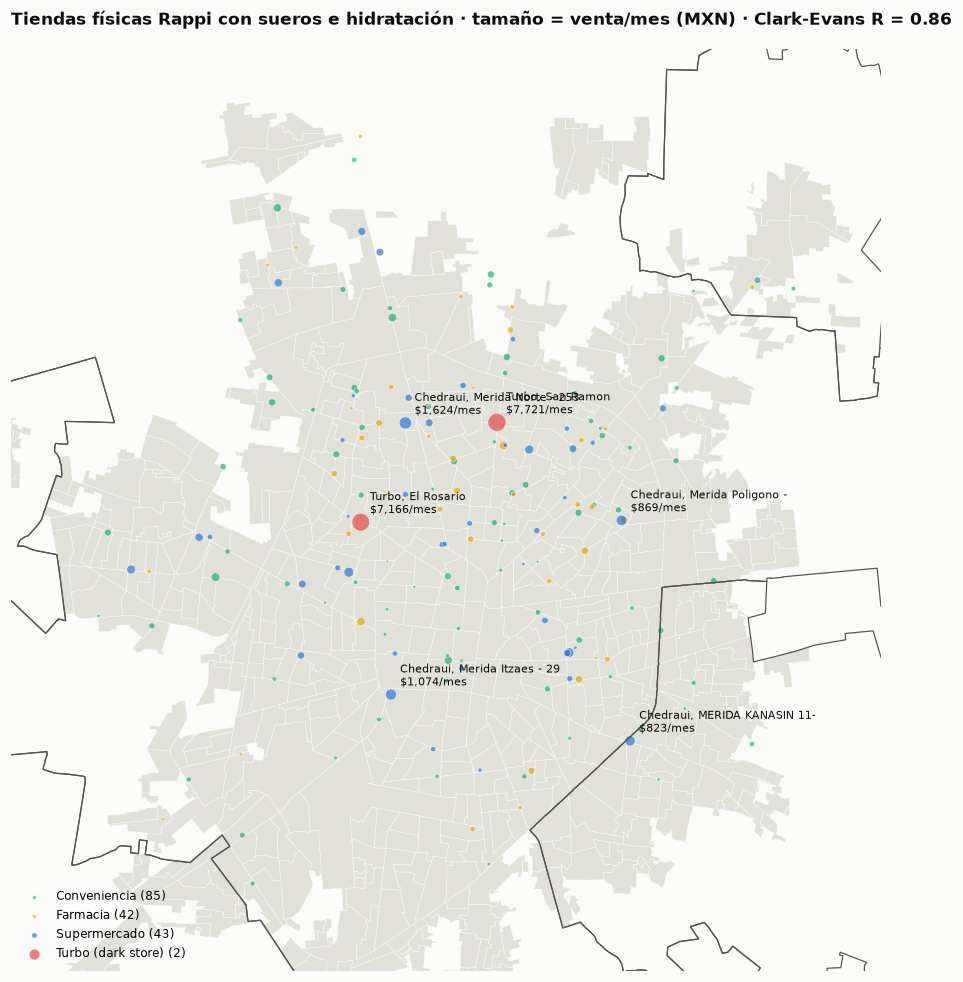

In [12]:
tf_g = gpd.GeoDataFrame(tf, geometry=gpd.points_from_xy(tf.lon, tf.lat), crs=4326).to_crs(mun.crs)
area_urbana = agebs.to_crs(mun.crs).area.sum()
XY_TF = np.radians(tf[["lat", "lon"]].to_numpy())
dd, _ = BallTree(XY_TF, metric="haversine").query(XY_TF, k=2)
nn = dd[:, 1] * R.RADIO_TIERRA_M
lam_ = len(tf) / area_urbana
esperada = 0.5 / np.sqrt(lam_)
ce = nn.mean() / esperada
z_ce = (nn.mean() - esperada) / (0.26136 / np.sqrt(len(tf) * lam_))
tipo_res = tf.groupby("tipo").agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum"), mediana_venta_mes=("venta_mes", "median"),
                                  venta_sueros_mes=("venta_sueros_mes", "sum"))
tipo_res["% venta"] = tipo_res.venta_mes / tipo_res.venta_mes.sum() * 100
tipo_res["% sueros en su venta"] = tipo_res.venta_sueros_mes / tipo_res.venta_mes * 100
display(tipo_res.sort_values("venta_mes", ascending=False).round(1))
top10 = tf.venta_mes.nlargest(10).sum() / tf.venta_mes.sum()
turbo_pct = tipo_res["% venta"].get(TIPO["TURBO"], 0)
ESPACIAL = (f"{len(tf)} tiendas físicas; Gini venta/mes = {eda.gini(tf.venta_mes):.2f}; las 10 más grandes hacen {top10:.0%} "
            f"(Turbo: {turbo_pct:.0f}% con {int(tipo_res.tiendas.get(TIPO['TURBO'], 0))} tiendas). Vecino más cercano: mediana "
            f"{np.median(nn):,.0f} m; Clark-Evans R = {ce:.2f} (z = {z_ce:.1f}): {'agrupadas' if ce < 1 else 'dispersas'} en el área urbana.")
print(ESPACIAL)
display(tf.groupby("municipio").agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum")).round(0))

fig, ax = plt.subplots(figsize=(10, 9))
agebs.to_crs(mun.crs).plot(ax=ax, color=eda.GRID, edgecolor=eda.FONDO, lw=0.3)
zm.boundary.plot(ax=ax, color=eda.TINTA_2, lw=0.8)
col_tipo = dict(zip(tipo_res.sort_values("venta_mes", ascending=False).index, [ROJO, AZUL, VERDE, AMBAR, MORADO, NARANJA, ROSA, VERDE2]))
for t_, g in tf_g.groupby("tipo"):
    g.plot(ax=ax, color=col_tipo[t_], markersize=np.sqrt(g.venta_mes) * 1.6, alpha=0.7, edgecolor=eda.FONDO, lw=0.5, label=f"{t_} ({len(g)})")
for _, r in tf_g.nlargest(6, "venta_mes").iterrows():
    ax.annotate(f"{r.nombre[:28]}\n${r.venta_mes:,.0f}/mes", (r.geometry.x, r.geometry.y), fontsize=7, xytext=(6, 6),
                textcoords="offset points", color=eda.TINTA)
ax.set_xlim(tf_g.total_bounds[[0, 2]] + np.array([-2500, 2500]))
ax.set_ylim(tf_g.total_bounds[[1, 3]] + np.array([-2500, 2500]))
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, markerscale=0.6)
ax.set_title(f"Tiendas físicas Rappi con sueros e hidratación · tamaño = venta/mes (MXN) · Clark-Evans R = {ce:.2f}")
plt.tight_layout(); plt.show()

## 9. Reglas de selección: qué pasa a las letras (notebook 06)

Se fijan **antes** de cruzar con Bepensa (el 06 hace el cruce y sus pruebas):

| Regla | Criterio | Si no se cumple |
|---|---|---|
| R1 universo | ZM por polígono, sueros y derivados ("sueros primero"), ventana ene-2025 → ago-2026 (sección 1) | no entra |
| R2 tienda activa | ≥ `C.RAPPI_MIN_PEDIDOS` pedidos de sueros o derivados en la ventana (uno cada ~2 meses): la demanda se repite | esporádica: se reporta; en el 06 entra al Rappi del buffer y su exclusión se prueba en la sensibilidad |
| R3 activa en sueros | ≥ `C.RAPPI_MIN_PEDIDOS` pedidos **con suero** | se reporta |
| R4 tipo | los Turbo (dark stores) se **marcan**: su venta es de toda su zona de reparto, no de sus 300 m | entra marcada (el 06 mide la sensibilidad sin ellos) |
| R5 señales | por tienda física: venta total y de sueros, pedidos y unidades por mes de vida, meses activos, % Coca-Cola, % pago en efectivo y Apple Pay | — |

In [13]:
tf["activa"] = tf.pedidos >= C.RAPPI_MIN_PEDIDOS
tf["activa_sueros"] = tf.pedidos_sueros >= C.RAPPI_MIN_PEDIDOS
tf["turbo"] = tf.tipo.eq(TIPO["TURBO"])
sel = tf.groupby(["activa", "activa_sueros"]).agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum"), pedidos=("pedidos", "sum"))
sel["% venta"] = sel.venta_mes / sel.venta_mes.sum() * 100
display(sel.round(1))
SELECCION = (f"R2: {int(tf.activa.sum())} de {len(tf)} tiendas físicas activas (≥ {C.RAPPI_MIN_PEDIDOS} pedidos) hacen "
             f"{tf.venta_mes[tf.activa].sum() / tf.venta_mes.sum():.1%} de la venta; R3: {int(tf.activa_sueros.sum())} activas en sueros; "
             f"R4: {int(tf.turbo.sum())} Turbo marcadas ({tf.venta_mes[tf.turbo].sum() / tf.venta_mes.sum():.0%} de la venta).")
print(SELECCION)

tiendas  venta_mes  pedidos  % venta
activa activa_sueros                                      
False  False               83  2,877.000      306    8.000
True   False               69  9,975.800     3147   27.800
       True                20 23,051.700     8318   64.200

R2: 89 de 172 tiendas físicas activas (≥ 12 pedidos) hacen 92.0% de la venta; R3: 20 activas en sueros; R4: 2 Turbo marcadas (41% de la venta).


## 10. QA de las decisiones: ¿cambia el resultado si la regla fuera otra?

Cada decisión de limpieza se prueba contra su alternativa: solo la subcategoría de Rappi (sin reglas 2-4), quitar
duplicados, empezar en oct-2024 (con los meses de cobertura incompleta), reloj UTC, radio de tienda física (10 / 50 m) y
umbral de tienda activa (1 / 6 / 24 pedidos).

In [14]:
solo_rappi = u.regla.str.startswith("1")
sin_dup = ~u.duplicated(COLS_ORIG)
cambia_mes = (u.fecha - pd.Timedelta(hours=6)).dt.strftime("%Y-%m") != u.mes
desde_oct = cand[cand.en_zm & cand.subcategoria.notna() & cand.fecha.between(pd.Timestamp("2024-10-01"), fin, inclusive="left")]
qa = [("Solo la subcategoría de Rappi (sin marca, nombre ni categoría)", f"{solo_rappi.mean():.1%} de las líneas",
       f"{u.beverage_sales[solo_rappi].sum() / u.beverage_sales.sum():.1%} de la venta; tiendas {u.tienda_fisica[solo_rappi].nunique()} de {u.tienda_fisica.nunique()}"),
      ("Quitar líneas idénticas", f"{sin_dup.mean():.1%} de las líneas", f"{u.beverage_sales[sin_dup].sum() / u.beverage_sales.sum():.1%} de la venta"),
      ("Empezar en oct-2024 (con los 3 meses de cobertura incompleta)", f"{len(desde_oct) / len(u) - 1:+.1%} líneas",
       f"{desde_oct.beverage_sales.sum() / u.beverage_sales.sum() - 1:+.1%} de venta, sin cadena, vertical ni BRAND_4866 en esos meses: sesga tendencias"),
      ("Reloj UTC (restar 6 h)", f"{cambia_mes.mean():.2%} de las líneas cambiaría de mes", f"{u.beverage_sales[cambia_mes].sum() / u.beverage_sales.sum():.2%} de la venta")]
for r_ in (10, 50):
    xy_ = xy.assign(t=R.tiendas_fisicas(xy.store_lat, xy.store_lng, r_))
    qa.append((f"Radio de tienda física {r_} m (base 25 m)", f"{xy_.t.nunique()} tiendas", f"vs {xy.tienda_fisica.nunique()} con 25 m"))
for m_ in (1, 6, 24):
    act = tf.pedidos >= m_
    qa.append((f"Tienda activa con ≥ {m_} pedidos (base {C.RAPPI_MIN_PEDIDOS})", f"{int(act.sum())} tiendas activas",
               f"{tf.venta_mes[act].sum() / tf.venta_mes.sum():.1%} de la venta"))
qa = pd.DataFrame(qa, columns=["alternativa", "efecto", "detalle"])
with pd.option_context("display.max_colwidth", None):
    display(qa)

,alternativa,efecto,detalle
0,"Solo la subcategoría de Rappi (sin marca, nombre ni categoría)",99.9% de las líneas,99.9% de la venta; tiendas 172 de 172
1,Quitar líneas idénticas,99.5% de las líneas,99.6% de la venta
2,Empezar en oct-2024 (con los 3 meses de cobertura incompleta),+13.5% líneas,"+11.5% de venta, sin cadena, vertical ni BRAND_4866 en esos meses: sesga tendencias"
3,Reloj UTC (restar 6 h),0.05% de las líneas cambiaría de mes,0.04% de la venta
4,Radio de tienda física 10 m (base 25 m),177 tiendas,vs 172 con 25 m
5,Radio de tienda física 50 m (base 25 m),170 tiendas,vs 172 con 25 m
6,Tienda activa con ≥ 1 pedidos (base 12),172 tiendas activas,100.0% de la venta
7,Tienda activa con ≥ 6 pedidos (base 12),107 tiendas activas,94.6% de la venta
8,Tienda activa con ≥ 24 pedidos (base 12),75 tiendas activas,88.5% de la venta


## 11. Salidas y hallazgos

In [15]:
lineas = u[["fecha", "mes", "order_code", "store_id", "store_name", "store_group_name", "vertical", "tienda_fisica", "store_lat", "store_lng",
            "cve_mun", "municipio", "subcategoria", "regla", "Product_Category_2", "Product_Category_3", "Product_Brand", "Product_Maker_Standard",
            "Product_name", "beverage_sales", "beverage_units", "precio_unitario", "multiempaque", "user_code", "age", "gender",
            "User_Attribute_1", "duplicada"]]
lineas.to_parquet(C.PROC / f"rappi_hidratacion_lineas_{C.SLUG}.parquet", index=False)
tiendas_out = tf.reset_index()
tiendas_out.to_parquet(C.PROC / f"rappi_hidratacion_tiendas_{C.SLUG}.parquet", index=False)
mensual.reset_index().to_parquet(C.PROC / f"rappi_hidratacion_mensual_{C.SLUG}.parquet", index=False)

hallazgos00c = pd.DataFrame([
    ("Universo", f"{len(u):,} líneas, {u.order_code.nunique():,} pedidos y ${u.beverage_sales.sum():,.0f} MXN de sueros y derivados en la "
                 f"{C.ZM_NOMBRE} ({mes_txt(ini)} → {mes_txt(cierre)}), de {len(nac):,} líneas nacionales.",
     "Es la única data de Rappi que se usa (ciudad activa, sueros e hidratación, ventana con cobertura completa)."),
    ("Ciudad", f"Etiquetas {sorted(etiquetas.city.unique())} = {C.RAPPI_CIUDAD}; dentro de la ZM con otra etiqueta: "
               f"{int((~cand.etiqueta_ciudad & cand.en_zm).sum())}; con la etiqueta y sin coordenadas: {int((cand.etiqueta_ciudad & ~con_xy).sum())}.",
     "La etiqueta y el polígono coinciden: el universo es el correcto."),
    ("Producto", "Regla 'sueros primero' en la ZM (ventana): " + "; ".join(f"{k} {int(v):,} líneas" for k, v in por_regla[f"líneas {C.ZM_NOMBRE} (ventana)"].items() if v)
                 + f". Pureza de marca {marcas.pureza.min():.2f}.",
     "Entran sueros y derivados aunque vengan fuera de su categoría; Vitamin Water entra como agua funcional de Coca-Cola (usuario, 2026-10-05); sale solo lo que no es hidratación (refrescos, agua sola)."),
    ("Cobertura y ventana", COBERTURA, "Crecimientos y tendencias solo en meses comparables (ene–ago)."),
    ("Reloj", RELOJ, "Los meses se asignan con la hora tal como viene."),
    ("Llave y duplicados", f"{LLAVE}. {DUPLICADOS}", "Grano = línea de pedido; no se borran líneas."),
    ("Tiendas físicas", TIENDAS, "El 06 cruza por tienda física (coordenada), no por store_id."),
    ("Faltantes", FALTANTES, "Clientes y producto solo se analizan en Coca-Cola; nada se imputa."),
    ("Colas y empaques", f"Importe por pedido: mediana ${ped.importe.median():.0f} (mejor ajuste {aj_ped.familia.iloc[0]}); venta/mes por tienda "
                         f"mediana ${tf.venta_mes.median():,.0f}, Gini {eda.gini(tf.venta_mes):.2f}, el 20% de las tiendas hace {top20:.0%}. {MULTI}",
     "Venta muy concentrada: medianas y rangos, no medias; precio sin empaques múltiples."),
    ("Calendario", "; ".join(f"{r.prueba}: {r.efecto} ({r.detalle.split(' ·')[0]})" for r in calendario.itertuples()),
     "La hidratación sigue al calor (abr–jun); el Rappi del 06 usa toda la ventana para no depender de la temporada."),
    ("Marcas", MARCAS, (f"Coca-Cola (sistema {C.CLIENTE_NOMBRE}) domina isotónicos; en sueros compite con marcas anonimizadas." if HAY_COMP else
      "Las marcas anonimizadas (BRAND_x) no se toman (usuario, 2026-10-05): el análisis es solo de Coca-Cola.")),
    ("Canasta", (f"Coca-Cola × competidor lift = {canasta.loc['Coca-Cola × competidor', 'lift']:.2f}; " if HAY_COMP else
                 f"Coca-Cola × competidor: {SIN_COMP}; ") + f"suero × isotónico lift = "
                f"{canasta.loc['suero × isotónico', 'lift']:.2f} (Fisher p = {canasta.loc['suero × isotónico', 'p Fisher']:.0e}).",
     "Lift < 1: el comprador elige una marca o subcategoría por pedido (sustitutos)."),
    ("Clientes", CLIENTES, "RFM solo con Coca-Cola (competidores sin usuario)."),
    ("Espacial", ESPACIAL, "Los Turbo concentran la venta: su zona de reparto es de km, no de 300 m (el 06 mide la sensibilidad sin ellos)."),
    ("Selección", SELECCION, "Pasan al 06 todas las tiendas físicas con sus señales (R5); el 06 prueba usar solo las activas (R2) y quitar los Turbo (R4)."),
], columns=["tema", "hallazgo", "implicación"])
with pd.option_context("display.max_colwidth", None):
    display(hallazgos00c)

import excel_kin as X


def para_excel(df):
    """Sí / No en vez de VERDADERO / FALSO."""
    return df.map(lambda v: ("Sí" if v else "No") if isinstance(v, (bool, np.bool_)) else v)


wb = X.libro()
X.hoja_tabla(wb, "Hallazgos", hallazgos00c.rename(columns=str.capitalize), titulo="Hallazgos del EDA de Rappi (sueros e hidratación)", ajustar=True,
             anchos={"Tema": 20, "Hallazgo": 105, "Implicación": 60})
X.hoja_tabla(wb, "Embudo", embudo.round(2), titulo="Qué queda en cada filtro",
             nota="Universo = tiendas en la ZM (polígono) · sueros y derivados ('sueros primero') · ventana con cobertura completa.",
             formatos={"líneas": "#,##0", "pedidos": "#,##0", "venta MXN": "#,##0", "store_id": "#,##0"}, anchos={"paso": 52})
X.hoja_tabla(wb, "Reglas producto", por_regla.round(0).rename_axis("regla"), indice=True, titulo="Regla que clasifica cada línea (ZM y país)",
             formatos={c: "#,##0" for c in por_regla.columns}, anchos={"regla": 58})
X.hoja_tabla(wb, "Excluidas", excluidas.round(0).rename_axis("motivo"), indice=True, titulo="Líneas de la ciudad que no entran y por qué",
             formatos={"venta_MXN": "#,##0"}, anchos={"motivo": 58, "ejemplos": 50})
X.hoja_tabla(wb, "Reasignación", reasignacion.round(2), titulo="Líneas clasificadas por marca, nombre o categoría (reglas 2-4) y Vitamin Water",
             anchos={"regla": 46, "subcategoria": 26})
X.hoja_tabla(wb, "Cobertura", cobertura.fillna(0).round(1).reset_index(), titulo="Cobertura del archivo por mes (todo el país)",
             nota="Meses sin cadena ni vertical y marcas grandes que aparecen tarde = cambio de cobertura, no de demanda.")
X.hoja_tabla(wb, "Tiendas", para_excel(tiendas_out.round(2)), titulo="Tiendas físicas Rappi con sueros e hidratación (señales para el 06)",
             nota=f"activa = ≥ {C.RAPPI_MIN_PEDIDOS} pedidos en la ventana; venta_mes = venta / meses de vida en la ventana (MXN).",
             formatos={"venta": "#,##0", "venta_mes": "#,##0", "venta_sueros_mes": "#,##0", "pedidos_mes": "0.0", "unidades_mes": "0.0",
                       "% sueros": "0.0", "% Coca-Cola": "0.0", "lat": "0.000000", "lon": "0.000000"}, barras=["venta_mes"], anchos={"nombre": 40})
X.hoja_tabla(wb, "Mensual", mensual.round(1).reset_index(), titulo="Serie mensual de la ZM", formatos={"venta": "#,##0", "ticket": "0.0"})
X.hoja_tabla(wb, "Calendario", calendario, titulo="Crecimiento y calendario", anchos={"prueba": 48, "detalle": 70})
X.hoja_tabla(wb, "Marcas", marcas_top.round(2), titulo="Marcas por venta" + ("" if not HAY_COMP else " (competidores anonimizados)"), formatos={"venta": "#,##0"})
X.hoja_tabla(wb, "Precio", precio.round(4), titulo="Precio por unidad sin empaques múltiples: Coca-Cola vs competidor")
X.hoja_tabla(wb, "Canasta", canasta.round(4).rename_axis("par"), indice=True, titulo="Co-compra en el mismo pedido (lift y Fisher)")
X.hoja_tabla(wb, "Univariado", uni.round(3).reset_index(), titulo="Univariado por nivel (línea, pedido, tienda)", anchos={"variable": 22, "lectura": 40})
X.hoja_tabla(wb, "QA decisiones", qa, titulo="Sensibilidad de cada decisión de limpieza", anchos={"alternativa": 58, "efecto": 32, "detalle": 60})
X.hoja_tabla(wb, "Datos", FUENTES_RAPPI, titulo="Archivo de Rappi usado", anchos={"ruta": 40, "sha256": 66})
X.portada(wb, "EDA de Rappi · sueros e hidratación", f"{C.ZM_NOMBRE} · sueros y derivados · {mes_txt(ini)} → {mes_txt(cierre)}",
          [("Universo", f"{len(u):,} líneas, {u.order_code.nunique():,} pedidos, {len(tf)} tiendas físicas."),
           ("Filtros", "Tienda dentro de la ZM (polígono); sueros y derivados con la regla 'sueros primero'; ventana con cobertura completa."),
           ("Uso", f"Letra 2 (notebook 06): el Rappi de cada PDV es la venta media de las tiendas Rappi a ≤ {C.RADIO_PDV_M} m; entra por rango con peso 1."),
           ("Elaboró", "Kin Analytics · notebooks/_src/00c_rappi_eda.py")],
          [("Hallazgos", "Qué se encontró y qué implica."), ("Embudo", "Qué queda en cada filtro."), ("Reglas producto", "Qué regla clasifica cada línea."),
           ("Excluidas", "Qué sale y por qué."), ("Reasignación", "Marca, nombre y categoría."), ("Cobertura", "Cobertura del archivo por mes."),
           ("Tiendas", "Tiendas físicas y sus señales."), ("Mensual", "Serie mensual."), ("Calendario", "Crecimiento, estacionalidad, día y quincena."),
           ("Marcas", "Marcas y fabricante."), ("Precio", "Precio por unidad."), ("Canasta", "Co-compra."), ("Univariado", "Colas y concentración."),
           ("QA decisiones", "Sensibilidad."), ("Datos", "Procedencia.")])
out = C.OUT / f"00c_rappi_hidratacion_eda_{C.SLUG}.xlsx"
wb.save(out)
print("Guardado:", out.name, "|", f"rappi_hidratacion_tiendas_{C.SLUG}.parquet ({len(tf)} tiendas, {int(tf.activa.sum())} activas)",
      "|", f"rappi_hidratacion_lineas_{C.SLUG}.parquet ({len(u):,} líneas)")

,tema,hallazgo,implicación
0,Universo,"13,130 líneas, 11,771 pedidos y $642,764 MXN de sueros y derivados en la ZM Mérida (ene-2025 → ago-2026), de 376,021 líneas nacionales.","Es la única data de Rappi que se usa (ciudad activa, sueros e hidratación, ventana con cobertura completa)."
1,Ciudad,"Etiquetas ['Merida', 'Mérida'] = ['MERIDA']; dentro de la ZM con otra etiqueta: 0; con la etiqueta y sin coordenadas: 4.",La etiqueta y el polígono coinciden: el universo es el correcto.
2,Producto,"Regla 'sueros primero' en la ZM (ventana): 0 · marca Coca-Cola de hidratación (Vitamin Water: agua funcional) 16 líneas; 1 · subcategoría de Rappi 13,114 líneas. Pureza de marca 1.00.","Entran sueros y derivados aunque vengan fuera de su categoría; Vitamin Water entra como agua funcional de Coca-Cola (usuario, 2026-10-05); sale solo lo que no es hidratación (refrescos, agua sola)."
3,Cobertura y ventana,"En 2024-10, 2024-11, 2024-12 el archivo no trae cadena ni vertical en todo el país: cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). La ventana empieza en ene-2025 (primer mes completo: 2025-01) y termina en ago-2026, igual que las ventas del cliente.",Crecimientos y tendencias solo en meses comparables (ene–ago).
4,Reloj,Líneas entre 1 y 6 h: 0.1% tal como viene vs 24.2% si fuera UTC: el reloj ya es hora local (no se convierte).,Los meses se asignan con la hora tal como viene.
5,Llave y duplicados,"11,771 pedidos · con más de una tienda: 0 · más de una fecha-hora: 0 · más de un usuario: 0. Líneas idénticas: Coca-Cola 0.9% (tienen código de barras; se conservan); competidores no aplica: sin las líneas BRAND_x quedan 0 líneas de competidores.",Grano = línea de pedido; no se borran líneas.
6,Tiendas físicas,"453 store_id y 184 coordenadas → 172 tiendas físicas (mediana 2 store_id por tienda, máx. 28); 0 store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).","El 06 cruza por tienda física (coordenada), no por store_id."
7,Faltantes,Usuario y producto vs competidores: no aplica: sin las líneas BRAND_x quedan 0 líneas de competidores. Edad: 37% sin dato y 0.0% con edad < 15 (inválida); género 'O' = 19%.,Clientes y producto solo se analizan en Coca-Cola; nada se imputa.
8,Colas y empaques,"Importe por pedido: mediana $38 (mejor ajuste lognorm); venta/mes por tienda mediana $66, Gini 0.75, el 20% de las tiendas hace 77%. Empaques múltiples (precio por 'unidad' > $150): 0 líneas (0.0%) y 0.0% de la venta. Box-Cox λ del importe por pedido = -0.79.","Venta muy concentrada: medianas y rangos, no medias; precio sin empaques múltiples."
9,Calendario,"Crecimiento ene–ago 2026 vs 2025 · venta total (Coca-Cola): +8.0% (IC95 bootstrap de semanas [-4.5%, +22.8%]); Crecimiento ene–ago 2026 vs 2025 · pedidos: -4.6% (IC95 bootstrap de semanas [-14.0%, +5.6%]); Estacionalidad por mes (Kruskal-Wallis): ε² = 0.249 (IC95 [0.210, 0.317]); Calor (abr–jun) vs fresca (nov–feb), venta diaria: δ = +0.49 (mediana $1,151 vs $769); Día de la semana (Kruskal-Wallis): ε² = 0.099 (IC95 [0.064, 0.163]); Quincena (días 15–17 y 30–2) vs resto: δ = +0.04 (p = 0.54)",La hidratación sigue al calor (abr–jun); el Rappi del 06 usa toda la ventana para no depender de la temporada.


Guardado: 00c_rappi_hidratacion_eda_zm_merida.xlsx | rappi_hidratacion_tiendas_zm_merida.parquet (172 tiendas, 89 activas) | rappi_hidratacion_lineas_zm_merida.parquet (13,130 líneas)
